<a href="https://colab.research.google.com/github/A-Vineela/HAR-Trial-and-Error/blob/main/02_Robust_Multiclass_Action_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Robust Multiclass Human Action Detection

**Goal :** build a multiclass action detection model, with a *primary* focus on
detailed performance analysis in the wild and on out-of-distribution (OOD) / failure cases — and,
as a secondary goal, try to close that gap using stronger approaches:

1. Transfer learning + a much better training recipe (this notebook)
2. A multi-step (hierarchical) classification approach
3. An incremental-training utility for adding new data later

This notebook picks up where `01_EDA.ipynb` left off. The baseline scratch CNN from that notebook
only reached **43.85% best validation accuracy**, and Grad-CAM showed it was leaning on background/
context rather than the action itself for several classes (e.g. everything with a laptop-shaped
object nearby getting predicted as `using_laptop`). Everything below is built to fix that, and then
to *measure* robustness explicitly rather than assume it.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Re-download the dataset (skip if already extracted from 01_EDA.ipynb in this runtime)
import os

if not os.path.exists("/content/HAR_dataset"):
    os.system(
        'wget -q -O /content/HAR_dataset.zip '
        '"https://www.kaggle.com/api/v1/datasets/download/meetnagadia/human-action-recognition-har-dataset"'
    )
    import zipfile
    with zipfile.ZipFile("/content/HAR_dataset.zip", "r") as z:
        z.extractall("/content/HAR_dataset")

print("Dataset ready:", os.path.exists("/content/HAR_dataset"))

Dataset ready: True


In [3]:
import pandas as pd

DATA_PATH = "/content/HAR_dataset/Human Action Recognition"
TRAIN_PATH = f"{DATA_PATH}/train"
TEST_PATH  = f"{DATA_PATH}/test"
TRAIN_CSV  = f"{DATA_PATH}/Training_set.csv"

train_df = pd.read_csv(TRAIN_CSV)
print("Training CSV:", train_df.shape)

Training CSV: (12600, 2)


## 1. Re-create the exact same split as the baseline

Same duplicate-aware, stratified, `random_state=42` split used in `01_EDA.ipynb`. This is
important: if the split changes, the baseline (40.8% final / 43.85% best) and the new model
aren't comparable anymore.


In [4]:
import hashlib
from collections import defaultdict
from sklearn.model_selection import train_test_split

def get_image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_files = defaultdict(list)
for filename in train_df["filename"]:
    path = os.path.join(TRAIN_PATH, filename)
    hash_to_files[get_image_hash(path)].append(filename)

duplicate_groups = {h: files for h, files in hash_to_files.items() if len(files) > 1}

file_to_group = {}
for group_id, files in enumerate(duplicate_groups.values()):
    for f in files:
        file_to_group[f] = group_id

next_group_id = len(duplicate_groups)
for filename in train_df["filename"]:
    if filename not in file_to_group:
        file_to_group[filename] = next_group_id
        next_group_id += 1

train_df["group_id"] = train_df["filename"].map(file_to_group)

groups = train_df.groupby("group_id").agg(label=("label", "first")).reset_index()

train_groups, val_groups = train_test_split(
    groups, test_size=0.20, stratify=groups["label"], random_state=42
)

train_group_ids = set(train_groups["group_id"])
val_group_ids = set(val_groups["group_id"])

train_split = train_df[train_df["group_id"].isin(train_group_ids)].copy()
val_split = train_df[train_df["group_id"].isin(val_group_ids)].copy()

print("Training samples:", len(train_split))
print("Validation samples:", len(val_split))
assert len(set(train_split["group_id"]) & set(val_split["group_id"])) == 0, "Leakage detected!"


Training samples: 10078
Validation samples: 2522


## 2. Data pipeline v2

Two changes from the baseline pipeline:

- **Aspect-ratio-preserving resize + padding** is used everywhere (this was flagged in the EDA as
  the safer choice — direct resize distorts poses).
- **Stronger, wider augmentation**: `TrivialAugmentWide` (search-free RandAugment variant) +
  `RandomErasing` (simulates occlusion) + `MixUp`/`CutMix` at the batch level. The baseline only
  used flip/rotation/color-jitter, which is weak relative to how little data we have per class
  (840 images/class) and is a big reason the scratch CNN overfit to background shortcuts.


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

class ResizeWithPadding:
    """ Aspect-ratio preserving resize onto a square canvas (from 01_EDA.ipynb). """
    def __init__(self, size):
        self.size = size

    def __call__(self, image):
        width, height = image.size
        scale = self.size / max(width, height)
        new_width, new_height = int(round(width * scale)), int(round(height * scale))
        image = image.resize((new_width, new_height), Image.Resampling.BILINEAR)
        canvas = Image.new("RGB", (self.size, self.size))
        left = (self.size - new_width) // 2
        top = (self.size - new_height) // 2
        canvas.paste(image, (left, top))
        return canvas


train_transform = transforms.Compose([
    ResizeWithPadding(IMG_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # simulates partial occlusion
])

val_transform = transforms.Compose([
    ResizeWithPadding(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [6]:
classes = sorted(train_df["label"].unique())
class_to_idx = {label: idx for idx, label in enumerate(classes)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}
NUM_CLASSES = len(classes)
print(NUM_CLASSES, "classes:", classes)

15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']


In [7]:
class HARDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        label = class_to_idx[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = HARDataset(train_split, TRAIN_PATH, transform=train_transform)
val_dataset   = HARDataset(val_split,   TRAIN_PATH, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 314 | Val batches: 79


In [8]:
def mixup_cutmix(images, labels, num_classes, alpha=0.2, cutmix_prob=0.5):
    """ Randomly applies MixUp or CutMix to a batch. Returns soft targets. """
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size, device=images.device)

    y_onehot = F.one_hot(labels, num_classes).float()
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[index]

    if np.random.rand() < cutmix_prob:
        H, W = images.shape[-2:]
        cut_rat = np.sqrt(1.0 - lam)
        cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
        cx, cy = np.random.randint(W), np.random.randint(H)
        x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)
        y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
        images[:, :, y1:y2, x1:x2] = images[index][:, :, y1:y2, x1:x2]
        lam_adj = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
        y_mixed = lam_adj * y_onehot + (1 - lam_adj) * y_onehot[index]
    else:
        images = lam * images + (1 - lam) * images[index]

    return images, y_mixed

## 3. Model: transfer learning instead of a scratch CNN

The baseline was a 4-block CNN trained from scratch on ~10k images — that's simply not enough
data to learn robust, generalizable features for 15 fine-grained human actions. Swapping to an
ImageNet-pretrained backbone (`EfficientNet-V2-S`) gives the model features that already encode
pose, texture, and object shape, so the classifier head only has to learn how to *combine* them
for these 15 classes.

Training strategy: **two phases**.
- Phase 1 — freeze the backbone, train only the new classifier head (fast, stabilizes the head
  before touching pretrained weights).
- Phase 2 — unfreeze the whole network and fine-tune end-to-end with a much smaller learning
  rate on the backbone than on the head (discriminative learning rates).


In [9]:
import torchvision
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

def build_model(num_classes=NUM_CLASSES, dropout=0.3):
    weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
    backbone = efficientnet_v2_s(weights=weights)
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return backbone

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device)
print("Device:", device)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 203MB/s]


Device: cuda
Trainable params: 20196703


In [10]:
def set_backbone_trainable(model, trainable: bool):
    for name, param in model.named_parameters():
        if not name.startswith("classifier"):
            param.requires_grad = trainable

# Phase 1: freeze backbone
set_backbone_trainable(model, trainable=False)
print("Frozen. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Frozen. Trainable params: 19215


## 4. Training recipe

Everything the baseline was missing:

| | Baseline | This notebook |
|---|---|---|
| Backbone | scratch CNN | ImageNet-pretrained EfficientNet-V2-S |
| Loss | plain cross-entropy | label-smoothed CE (+ soft targets from MixUp/CutMix) |
| Optimizer | Adam, flat LR | AdamW, discriminative LR (head ≫ backbone) |
| Schedule | none | cosine decay with linear warmup |
| Regularization | none | weight decay, dropout, RandomErasing, MixUp/CutMix, gradient clipping |
| Precision | fp32 | mixed precision (AMP) |
| Stopping | fixed 20 epochs | early stopping on val accuracy + best-checkpoint restore |
| EMA | none | exponential moving average of weights for eval |


In [11]:
from torch.optim.lr_scheduler import LambdaLR
import math, copy

class EMA:
    """ Exponential moving average of model weights - usually evaluates ~0.5-1pt higher and is
    much more stable on the wild/OOD sets than the raw weights. """
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, p in zip(self.shadow.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(p.detach(), alpha=1 - self.decay)
        for ema_b, b in zip(self.shadow.buffers(), model.buffers()):
            ema_b.copy_(b)


def cosine_warmup_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)


def soft_ce_loss(logits, soft_targets, smoothing=0.1):
    n_classes = logits.size(1)
    soft_targets = soft_targets * (1 - smoothing) + smoothing / n_classes
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

In [12]:
def train_one_phase(model, train_loader, val_loader, epochs, head_lr, backbone_lr,
                     use_mixup=True, patience=5, ema_decay=0.999, grad_clip=1.0):
    head_params = [p for n, p in model.named_parameters() if n.startswith("classifier")]
    backbone_params = [p for n, p in model.named_parameters()
                        if not n.startswith("classifier") and p.requires_grad]

    param_groups = [{"params": head_params, "lr": head_lr}]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": backbone_lr})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    total_steps = epochs * len(train_loader)
    scheduler = cosine_warmup_scheduler(optimizer, warmup_steps=int(0.05 * total_steps),
                                         total_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler()
    ema = EMA(model, decay=ema_decay)

    best_val_acc, best_state, epochs_no_improve = 0.0, None, 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                if use_mixup:
                    mixed_images, soft_targets = mixup_cutmix(images.clone(), labels, NUM_CLASSES)
                    outputs = model(mixed_images)
                    loss = soft_ce_loss(outputs, soft_targets)
                else:
                    outputs = model(images)
                    loss = F.cross_entropy(outputs, labels, label_smoothing=0.1)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ema.update(model)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss, train_acc = running_loss / total, correct / total

        val_loss, val_acc = evaluate(ema.shadow, val_loader)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(ema.shadow.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return running_loss / total, correct / total

In [13]:
# Phase 1 - head-only warmup (backbone frozen)
model, history_p1, val_acc_p1 = train_one_phase(
    model, train_loader, val_loader,
    epochs=5, head_lr=1e-3, backbone_lr=0.0,
    use_mixup=False, patience=5,
)
print("Phase 1 best val acc:", val_acc_p1)

/tmp/ipykernel_622/2292080447.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_622/2292080447.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 | train_loss=2.1439 train_acc=0.3727 | val_loss=2.4124 val_acc=0.3759
Epoch 2/5 | train_loss=1.8279 train_acc=0.4930 | val_loss=2.0189 val_acc=0.5262
Epoch 3/5 | train_loss=1.7723 train_acc=0.5176 | val_loss=1.7716 val_acc=0.5603
Epoch 4/5 | train_loss=1.7500 train_acc=0.5306 | val_loss=1.6188 val_acc=0.5694
Epoch 5/5 | train_loss=1.7408 train_acc=0.5306 | val_loss=1.5414 val_acc=0.5738
Phase 1 best val acc: 0.5737509912767644


In [14]:
# Phase 2 - full fine-tune, discriminative LR, MixUp/CutMix on
set_backbone_trainable(model, trainable=True)

model, history_p2, val_acc_p2 = train_one_phase(
    model, train_loader, val_loader,
    epochs=30, head_lr=5e-4, backbone_lr=5e-5,
    use_mixup=True, patience=7,
)
print("Phase 2 best val acc:", val_acc_p2)

/tmp/ipykernel_622/2292080447.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_622/2292080447.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30 | train_loss=1.9818 train_acc=0.3549 | val_loss=1.5176 val_acc=0.5813
Epoch 2/30 | train_loss=1.7302 train_acc=0.4205 | val_loss=1.4089 val_acc=0.6158
Epoch 3/30 | train_loss=1.5476 train_acc=0.4728 | val_loss=1.2198 val_acc=0.6685
Epoch 4/30 | train_loss=1.4743 train_acc=0.4793 | val_loss=1.1397 val_acc=0.7070
Epoch 5/30 | train_loss=1.3733 train_acc=0.5128 | val_loss=0.9799 val_acc=0.7486
Epoch 6/30 | train_loss=1.3160 train_acc=0.5343 | val_loss=0.8812 val_acc=0.7827
Epoch 7/30 | train_loss=1.2908 train_acc=0.5001 | val_loss=0.7830 val_acc=0.7998
Epoch 8/30 | train_loss=1.3022 train_acc=0.5407 | val_loss=0.7428 val_acc=0.8025
Epoch 9/30 | train_loss=1.1953 train_acc=0.5479 | val_loss=0.6677 val_acc=0.8180
Epoch 10/30 | train_loss=1.1933 train_acc=0.6046 | val_loss=0.6829 val_acc=0.8236
Epoch 11/30 | train_loss=1.2420 train_acc=0.5411 | val_loss=0.6798 val_acc=0.8311
Epoch 12/30 | train_loss=1.1875 train_acc=0.5742 | val_loss=0.7292 val_acc=0.8291
Epoch 13/30 | train_loss=

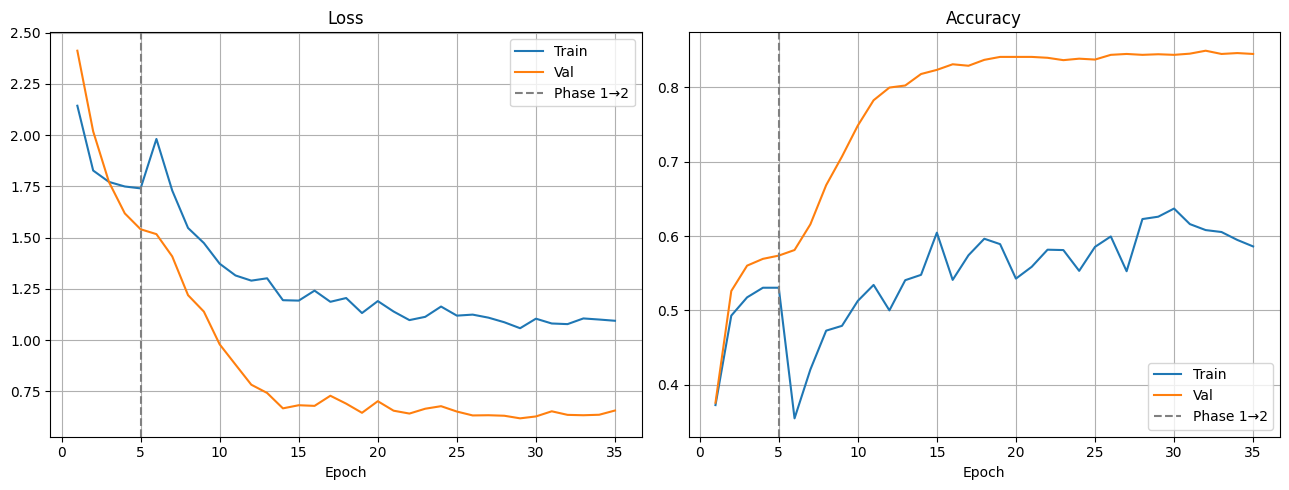

Baseline best val accuracy (01_EDA.ipynb): 0.4385
This model's best val accuracy: 0.8493


In [15]:
import matplotlib.pyplot as plt

full_history = {k: history_p1[k] + history_p2[k] for k in history_p1}
epochs_range = range(1, len(full_history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs_range, full_history["train_loss"], label="Train")
axes[0].plot(epochs_range, full_history["val_loss"], label="Val")
axes[0].axvline(len(history_p1["train_loss"]), color="gray", linestyle="--", label="Phase 1→2")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, full_history["train_acc"], label="Train")
axes[1].plot(epochs_range, full_history["val_acc"], label="Val")
axes[1].axvline(len(history_p1["train_acc"]), color="gray", linestyle="--", label="Phase 1→2")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

print("Baseline best val accuracy (01_EDA.ipynb): 0.4385")
print(f"This model's best val accuracy: {max(val_acc_p1, val_acc_p2):.4f}")

In [16]:
checkpoint_path = "/content/drive/MyDrive/har_effnetv2s_finetuned.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "architecture": "efficientnet_v2_s",
    "num_classes": NUM_CLASSES,
    "class_to_idx": class_to_idx,
    "input_size": IMG_SIZE,
    "best_val_accuracy": max(val_acc_p1, val_acc_p2),
}, checkpoint_path)
print("Saved to:", checkpoint_path)

Saved to: /content/drive/MyDrive/har_effnetv2s_finetuned.pth


## 5. Standard validation analysis

Same confusion matrix / classification report treatment as the baseline notebook, for a direct
before/after comparison.


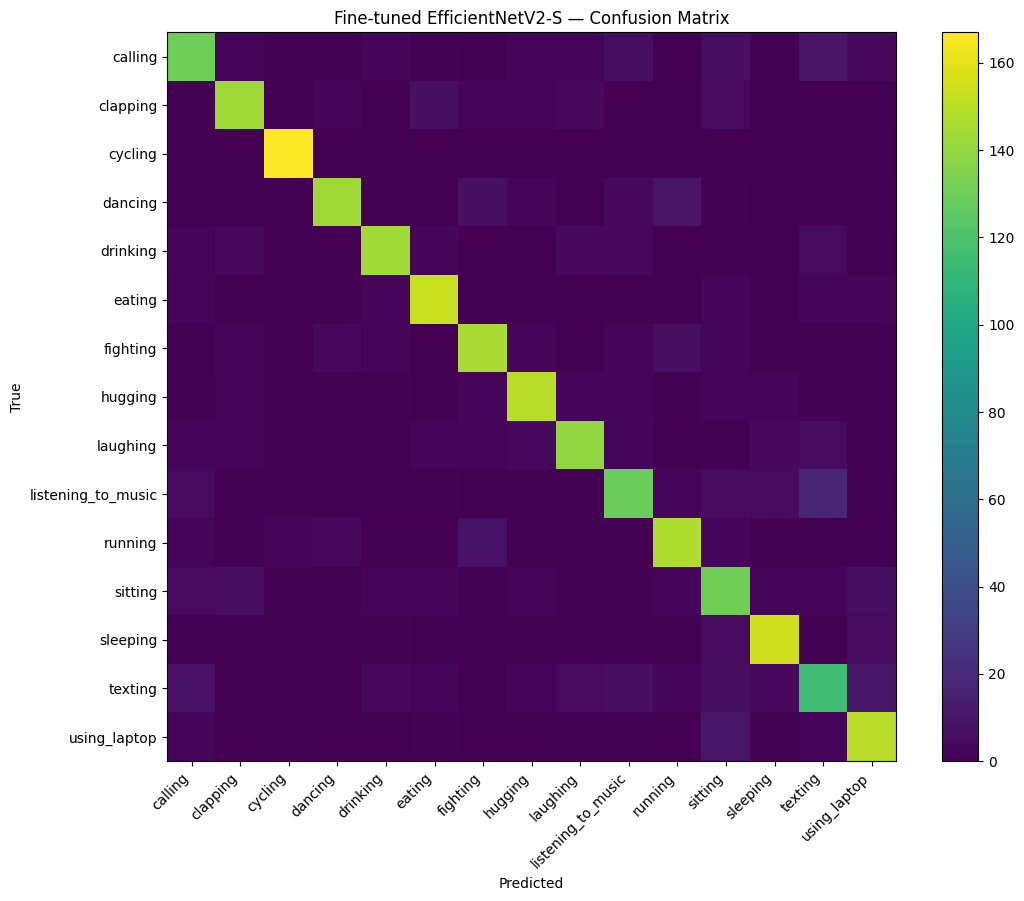

                    precision    recall  f1-score   support

           calling     0.7927    0.7738    0.7831       168
          clapping     0.8563    0.8462    0.8512       169
           cycling     0.9709    0.9940    0.9824       168
           dancing     0.8994    0.8512    0.8746       168
          drinking     0.8834    0.8571    0.8701       168
            eating     0.8844    0.9107    0.8974       168
          fighting     0.8639    0.8639    0.8639       169
           hugging     0.8765    0.8922    0.8843       167
          laughing     0.8750    0.8333    0.8537       168
listening_to_music     0.8113    0.7679    0.7890       168
           running     0.8647    0.8802    0.8724       167
           sitting     0.7198    0.7798    0.7486       168
          sleeping     0.8857    0.9172    0.9012       169
           texting     0.7296    0.6864    0.7073       169
      using_laptop     0.8278    0.8869    0.8563       168

          accuracy                    

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

class_names = classes
all_predictions, all_labels = get_predictions(model, val_loader)

cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(11, 9))
plt.imshow(cm, interpolation="nearest")
plt.title("Fine-tuned EfficientNetV2-S — Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.tight_layout(); plt.show()

print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))

## 6. Wild / OOD robustness suite — the main deliverable

Clean validation accuracy alone does *not* tell us how the model behaves "in the wild." Real-world
images differ from this dataset in lighting, compression, camera shake, partial occlusion, and
framing. To actually measure that gap we build a **corrupted validation benchmark** (in the spirit
of ImageNet-C) with 8 corruption types × 3 severities, evaluate both the baseline and the fine-tuned
model on it, and look at where accuracy falls off a cliff.


In [18]:
import cv2

def add_gaussian_noise(img, severity):
    sigma = [0.03, 0.08, 0.15][severity]
    arr = np.array(img).astype(np.float32) / 255.0
    noisy = arr + np.random.normal(0, sigma, arr.shape)
    return Image.fromarray((np.clip(noisy, 0, 1) * 255).astype(np.uint8))

def add_gaussian_blur(img, severity):
    k = [3, 7, 13][severity]
    arr = cv2.GaussianBlur(np.array(img), (k, k), 0)
    return Image.fromarray(arr)

def add_motion_blur(img, severity):
    k = [5, 11, 17][severity]
    kernel = np.zeros((k, k)); kernel[k // 2, :] = 1.0 / k
    arr = cv2.filter2D(np.array(img), -1, kernel)
    return Image.fromarray(arr)

def adjust_brightness(img, severity):
    factor = [0.6, 0.4, 0.25][severity]  # simulate low light
    return transforms.functional.adjust_brightness(img, factor)

def adjust_contrast(img, severity):
    factor = [0.6, 0.4, 0.25][severity]
    return transforms.functional.adjust_contrast(img, factor)

def jpeg_compress(img, severity):
    quality = [40, 20, 10][severity]
    arr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    _, enc = cv2.imencode(".jpg", arr, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return Image.fromarray(cv2.cvtColor(dec, cv2.COLOR_BGR2RGB))

def occlusion(img, severity):
    frac = [0.15, 0.30, 0.45][severity]  # fraction of shorter side blacked out
    arr = np.array(img).copy()
    h, w = arr.shape[:2]
    size = int(min(h, w) * frac)
    y = np.random.randint(0, max(1, h - size))
    x = np.random.randint(0, max(1, w - size))
    arr[y:y + size, x:x + size] = 0
    return Image.fromarray(arr)

def background_shift(img, severity):
    factor = [0.05, 0.15, 0.3][severity]
    return transforms.functional.adjust_hue(img, factor)
# background_shift is a crude proxy for a different scene (hue rotation on everything).
# A real background-swap needs segmentation; this at least stresses context-shortcut reliance.

CORRUPTIONS = {
    "gaussian_noise": add_gaussian_noise,
    "gaussian_blur": add_gaussian_blur,
    "motion_blur": add_motion_blur,
    "low_light": adjust_brightness,
    "low_contrast": adjust_contrast,
    "jpeg_compression": jpeg_compress,
    "occlusion": occlusion,
    "hue_shift": background_shift,
}
print("Corruption types:", list(CORRUPTIONS.keys()))

Corruption types: ['gaussian_noise', 'gaussian_blur', 'motion_blur', 'low_light', 'low_contrast', 'jpeg_compression', 'occlusion', 'hue_shift']


In [19]:
class CorruptedHARDataset(Dataset):
    """ Applies one corruption at one severity, then the normal (no-augmentation) eval transform. """
    def __init__(self, dataframe, image_dir, corruption_fn, severity):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.corruption_fn = corruption_fn
        self.severity = severity
        self.post = transforms.Compose([
            ResizeWithPadding(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        if self.corruption_fn is not None:
            image = self.corruption_fn(image, self.severity)
        image = self.post(image)
        label = class_to_idx[row["label"]]
        return image, label

In [20]:
def evaluate_robustness(model, dataframe, image_dir, corruptions, severities=(0, 1, 2), batch_size=32):
    results = {}
    for name, fn in corruptions.items():
        for sev in severities:
            ds = CorruptedHARDataset(dataframe, image_dir, fn, sev)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
            _, acc = evaluate(model, loader)
            results[(name, sev)] = acc
            print(f"{name:18s} severity={sev} -> val_acc={acc:.4f}")
    return results

print("Evaluating fine-tuned model on the wild/OOD benchmark (this will take a while)...")
robustness_results = evaluate_robustness(model, val_split, TRAIN_PATH, CORRUPTIONS)

Evaluating fine-tuned model on the wild/OOD benchmark (this will take a while)...
gaussian_noise     severity=0 -> val_acc=0.8402
gaussian_noise     severity=1 -> val_acc=0.8196
gaussian_noise     severity=2 -> val_acc=0.7843
gaussian_blur      severity=0 -> val_acc=0.8343
gaussian_blur      severity=1 -> val_acc=0.7902
gaussian_blur      severity=2 -> val_acc=0.7121
motion_blur        severity=0 -> val_acc=0.8113
motion_blur        severity=1 -> val_acc=0.6816
motion_blur        severity=2 -> val_acc=0.5511
low_light          severity=0 -> val_acc=0.8485
low_light          severity=1 -> val_acc=0.8481
low_light          severity=2 -> val_acc=0.8458
low_contrast       severity=0 -> val_acc=0.8442
low_contrast       severity=1 -> val_acc=0.8442
low_contrast       severity=2 -> val_acc=0.8426
jpeg_compression   severity=0 -> val_acc=0.8398
jpeg_compression   severity=1 -> val_acc=0.8188
jpeg_compression   severity=2 -> val_acc=0.7803
occlusion          severity=0 -> val_acc=0.8406
occlus

In [21]:
import pandas as pd

rows = []
for (name, sev), acc in robustness_results.items():
    rows.append({"corruption": name, "severity": sev, "val_accuracy": acc})
robustness_df = pd.DataFrame(rows)

clean_acc = evaluate(model, val_loader)[1]
robustness_df = pd.concat([
    pd.DataFrame([{"corruption": "clean", "severity": -1, "val_accuracy": clean_acc}]),
    robustness_df,
], ignore_index=True)

pivot = robustness_df[robustness_df.corruption != "clean"].pivot(
    index="corruption", columns="severity", values="val_accuracy"
)
pivot["mean_over_severity"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_over_severity")

print(f"Clean validation accuracy: {clean_acc:.4f}")
print()
print(pivot)

mCE_style_score = pivot["mean_over_severity"].mean()
print()
print(f"Mean accuracy across all corruptions/severities ('wild score'): {mCE_style_score:.4f}")
print(f"Robustness gap vs clean: {clean_acc - mCE_style_score:.4f}")

Clean validation accuracy: 0.8493

severity                 0         1         2  mean_over_severity
corruption                                                        
motion_blur       0.811261  0.681602  0.551150            0.681338
gaussian_blur     0.834259  0.790246  0.712133            0.778879
hue_shift         0.833862  0.796987  0.758921            0.796590
occlusion         0.840603  0.814036  0.756146            0.803595
jpeg_compression  0.839810  0.818795  0.780333            0.812979
gaussian_noise    0.840206  0.819588  0.784298            0.814697
low_contrast      0.844171  0.844171  0.842585            0.843643
low_light         0.848533  0.848136  0.845757            0.847476

Mean accuracy across all corruptions/severities ('wild score'): 0.7974
Robustness gap vs clean: 0.0519


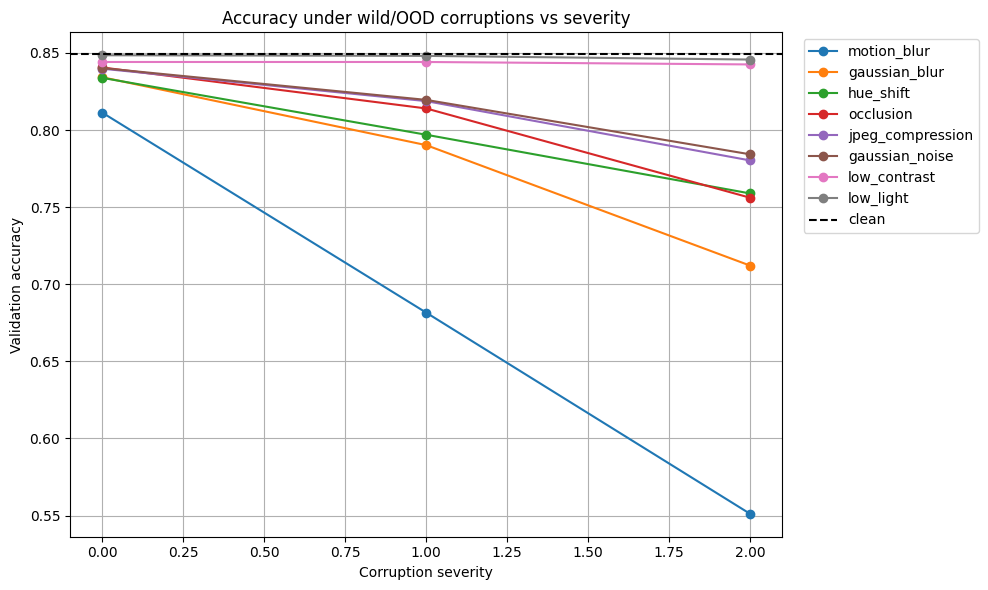

In [22]:
plt.figure(figsize=(10, 6))
for corruption in pivot.index:
    plt.plot([0, 1, 2], pivot.loc[corruption, [0, 1, 2]], marker="o", label=corruption)
plt.axhline(clean_acc, color="black", linestyle="--", label="clean")
plt.xlabel("Corruption severity"); plt.ylabel("Validation accuracy")
plt.title("Accuracy under wild/OOD corruptions vs severity")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True); plt.tight_layout(); plt.show()

**How to read this:** the corruptions the model degrades on fastest (lowest curves,
steepest slope) are the ones telling you *what* the model actually relies on. If `occlusion`
and `hue_shift` cause the biggest drops, that's consistent with the baseline's Grad-CAM finding
that it leans on background/context rather than pose — worth re-running the Grad-CAM cells below
under corruption to check whether fine-tuning actually fixed that or just made the model more
confident about the same shortcut.


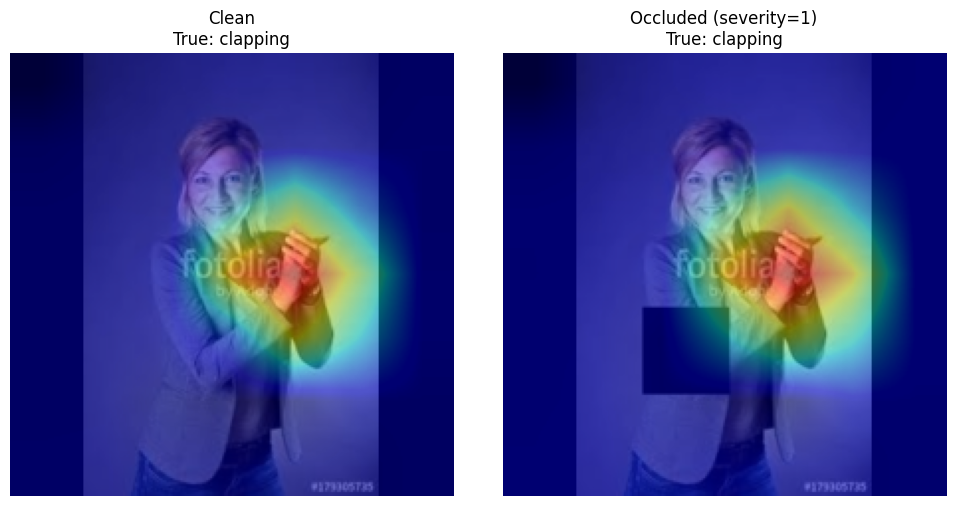

In [23]:
def generate_gradcam(model, image_tensor, target_class, target_layer):
    model.eval()
    activations, gradients = [], []

    def forward_hook(module, inp, out):
        activations.append(out)
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    image_tensor = image_tensor.unsqueeze(0).to(device)
    output = model(image_tensor)
    model.zero_grad()
    output[0, target_class].backward()

    activation = activations[0].detach()
    gradient = gradients[0].detach()
    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * activation).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    fh.remove(); bh.remove()
    return cam

def denormalize(image_tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return torch.clamp(image, 0, 1).permute(1, 2, 0).numpy()

# EfficientNetV2-S's last conv block, for Grad-CAM
gradcam_layer = model.features[-1]

sample_row = val_split.iloc[0]
clean_img = Image.open(os.path.join(TRAIN_PATH, sample_row["filename"])).convert("RGB")
occluded_img = occlusion(clean_img, severity=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, title in zip(axes, [clean_img, occluded_img], ["Clean", "Occluded (severity=1)"]):
    tensor = val_transform(img)
    true_idx = class_to_idx[sample_row["label"]]
    cam = generate_gradcam(model, tensor, true_idx, gradcam_layer)
    ax.imshow(denormalize(tensor))
    ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_title(f"{title}\nTrue: {sample_row['label']}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Multi-step (hierarchical) classification

Idea: instead of one 15-way classifier, split the problem into a coarse stage that's easy to get
right (fewer, more visually distinct groups) and a fine stage that only has to disambiguate within
a group. This directly targets the baseline's worst confusion cluster
(`sitting` / `calling` / `using_laptop` / `texting` / `listening_to_music` all collapsing toward
`using_laptop`) by giving the model an explicit "these are all screen/seated activities" grouping
to reason within, rather than competing against `cycling` or `fighting` in the same softmax.


In [24]:
# Coarse grouping - adjust based on what the confusion matrix above actually shows
COARSE_GROUPS = {
    "seated_screen":     ["sitting", "using_laptop", "texting", "calling", "listening_to_music"],
    "solo_dynamic":      ["running", "cycling", "dancing", "sleeping"],
    "interpersonal":     ["hugging", "fighting", "laughing", "clapping"],
    "eating_drinking":   ["eating", "drinking"],
}
FINE_TO_COARSE = {fine: coarse for coarse, fines in COARSE_GROUPS.items() for fine in fines}

# sanity check every class got a group
missing = set(classes) - set(FINE_TO_COARSE)
assert not missing, f"Unassigned classes, fix COARSE_GROUPS: {missing}"

coarse_classes = sorted(COARSE_GROUPS.keys())
coarse_to_idx = {c: i for i, c in enumerate(coarse_classes)}

train_split["coarse_label"] = train_split["label"].map(FINE_TO_COARSE)
val_split["coarse_label"] = val_split["label"].map(FINE_TO_COARSE)
print(train_split["coarse_label"].value_counts())

coarse_label
seated_screen      3359
solo_dynamic       2688
interpersonal      2687
eating_drinking    1344
Name: count, dtype: int64


In [25]:
class HierarchicalModel(nn.Module):
    """ Shared EfficientNet-V2-S trunk, two heads: coarse group + fine class. Fine logits are
    additively biased toward the predicted coarse group's members at inference time. """
    def __init__(self, num_coarse, num_fine, dropout=0.3):
        super().__init__()
        weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = efficientnet_v2_s(weights=weights)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.trunk = backbone
        self.dropout = nn.Dropout(dropout)
        self.coarse_head = nn.Linear(in_features, num_coarse)
        self.fine_head = nn.Linear(in_features, num_fine)

    def forward(self, x):
        feats = self.dropout(self.trunk(x))
        return self.coarse_head(feats), self.fine_head(feats)


hier_model = HierarchicalModel(len(coarse_classes), NUM_CLASSES).to(device)

# Group-mask: which fine classes are valid for each coarse group (for the inference-time bias)
group_mask = torch.zeros(len(coarse_classes), NUM_CLASSES)
for coarse, fines in COARSE_GROUPS.items():
    for f in fines:
        group_mask[coarse_to_idx[coarse], class_to_idx[f]] = 1.0
group_mask = group_mask.to(device)
print(group_mask.shape)

torch.Size([4, 15])


In [26]:
class HARDatasetHier(HARDataset):
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        fine_label = class_to_idx[row["label"]]
        coarse_label = coarse_to_idx[row["coarse_label"]]
        if self.transform:
            image = self.transform(image)
        return image, fine_label, coarse_label


hier_train_ds = HARDatasetHier(train_split, TRAIN_PATH, transform=train_transform)
hier_val_ds   = HARDatasetHier(val_split, TRAIN_PATH, transform=val_transform)
hier_train_loader = DataLoader(hier_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
hier_val_loader   = DataLoader(hier_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


def train_hierarchical(model, train_loader, val_loader, epochs=25, lr_head=5e-4, lr_backbone=5e-5,
                        coarse_weight=0.3, patience=6):
    param_groups = [
        {"params": list(model.coarse_head.parameters()) + list(model.fine_head.parameters()), "lr": lr_head},
        {"params": model.trunk.parameters(), "lr": lr_backbone},
    ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    total_steps = epochs * len(train_loader)
    scheduler = cosine_warmup_scheduler(optimizer, warmup_steps=int(0.05 * total_steps), total_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler()

    best_acc, best_state, no_improve = 0.0, None, 0

    for epoch in range(epochs):
        model.train()
        for images, fine_labels, coarse_labels in train_loader:
            images = images.to(device); fine_labels = fine_labels.to(device); coarse_labels = coarse_labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                coarse_logits, fine_logits = model(images)
                loss = (F.cross_entropy(fine_logits, fine_labels, label_smoothing=0.1)
                        + coarse_weight * F.cross_entropy(coarse_logits, coarse_labels, label_smoothing=0.1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()

        acc = evaluate_hierarchical(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | hierarchical val fine-acc={acc:.4f}")
        if acc > best_acc:
            best_acc, best_state, no_improve = acc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping."); break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_acc


@torch.no_grad()
def evaluate_hierarchical(model, loader, bias_strength=2.0):
    model.eval()
    correct, total = 0, 0
    for images, fine_labels, coarse_labels in loader:
        images = images.to(device); fine_labels = fine_labels.to(device)
        coarse_logits, fine_logits = model(images)
        coarse_pred = coarse_logits.argmax(dim=1)
        bias = group_mask[coarse_pred] * bias_strength
        fine_pred = (fine_logits + bias).argmax(dim=1)
        correct += (fine_pred == fine_labels).sum().item()
        total += fine_labels.size(0)
    return correct / total


hier_model, hier_best_acc = train_hierarchical(hier_model, hier_train_loader, hier_val_loader)
print()
print(f"Flat fine-tuned model best val acc: {max(val_acc_p1, val_acc_p2):.4f}")
print(f"Hierarchical model best val acc:     {hier_best_acc:.4f}")

/tmp/ipykernel_622/2587736785.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_622/2587736785.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/25 | hierarchical val fine-acc=0.6431
Epoch 2/25 | hierarchical val fine-acc=0.7752
Epoch 3/25 | hierarchical val fine-acc=0.8037
Epoch 4/25 | hierarchical val fine-acc=0.8236
Epoch 5/25 | hierarchical val fine-acc=0.8251
Epoch 6/25 | hierarchical val fine-acc=0.8232
Epoch 7/25 | hierarchical val fine-acc=0.8347
Epoch 8/25 | hierarchical val fine-acc=0.8311
Epoch 9/25 | hierarchical val fine-acc=0.8358
Epoch 10/25 | hierarchical val fine-acc=0.8358
Epoch 11/25 | hierarchical val fine-acc=0.8430
Epoch 12/25 | hierarchical val fine-acc=0.8347
Epoch 13/25 | hierarchical val fine-acc=0.8323
Epoch 14/25 | hierarchical val fine-acc=0.8382
Epoch 15/25 | hierarchical val fine-acc=0.8374
Epoch 16/25 | hierarchical val fine-acc=0.8351
Epoch 17/25 | hierarchical val fine-acc=0.8370
Early stopping.

Flat fine-tuned model best val acc: 0.8493
Hierarchical model best val acc:     0.8430


If the hierarchical accuracy beats the flat model, keep it and re-run the confusion-matrix
and wild/OOD cells above on `hier_model` (swap the `evaluate` calls for `evaluate_hierarchical`).
If it doesn't beat the flat model, that itself is a useful negative result worth writing up — it
tells you the confusion isn't really about missing hierarchy, and effort is better spent on data
(more occlusion-heavy training examples, hard-negative mining, etc).


## 8. Incremental training utility

For adding a new dataset/new classes later without retraining from scratch and without catastrophic
forgetting of the original 15 classes. Two ingredients:
- **Replay**: keep a small buffer of original-class examples and mix them into the new training data.
- **Low LR + short schedule** on the already-trained checkpoint, so old representations shift as
  little as possible.


In [27]:
def build_replay_buffer(dataframe, per_class=40, seed=42):
    return (dataframe.groupby("label", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))
            .reset_index(drop=True))


def incremental_finetune(model, checkpoint_path, new_df, new_image_dir, old_train_df,
                          replay_per_class=40, epochs=8, lr_head=2e-4, lr_backbone=2e-5):
    # model            : an already-trained model (e.g. `model` from section 4)
    # checkpoint_path  : path to save the updated checkpoint
    # new_df           : dataframe for the NEW data (needs 'filename' and 'label' columns;
    #                    new labels must be added to class_to_idx before calling this)
    # new_image_dir    : image directory for the new data
    # old_train_df     : the ORIGINAL train_split, used to build the replay buffer
    replay_df = build_replay_buffer(old_train_df, per_class=replay_per_class)

    combined_new = HARDataset(new_df, new_image_dir, transform=train_transform)
    combined_replay = HARDataset(replay_df, TRAIN_PATH, transform=train_transform)
    combined_ds = torch.utils.data.ConcatDataset([combined_new, combined_replay])
    combined_loader = DataLoader(combined_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=2, drop_last=True)

    model, history, best_acc = train_one_phase(
        model, combined_loader, val_loader,  # still validate against the original held-out set
        epochs=epochs, head_lr=lr_head, backbone_lr=lr_backbone,
        use_mixup=False, patience=4,
    )

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "num_classes": len(class_to_idx),
    }, checkpoint_path)

    print(f"Incremental checkpoint saved to {checkpoint_path}. "
          f"Val accuracy on original held-out set after update: {best_acc:.4f}")
    return model, history

# Usage once a new dataset is available, e.g.:
# for new_label in new_df["label"].unique():
#     if new_label not in class_to_idx:
#         class_to_idx[new_label] = len(class_to_idx)
#         idx_to_class[class_to_idx[new_label]] = new_label
# model = expand_classifier_head(model, new_num_classes=len(class_to_idx))  # implement per architecture
# model, _ = incremental_finetune(model, "/content/drive/MyDrive/har_v2.pth", new_df, NEW_IMAGE_DIR, train_split)
print("Incremental-training utility defined. Call incremental_finetune(...) once new data exists.")

Incremental-training utility defined. Call incremental_finetune(...) once new data exists.
